In [13]:
import os
import sys
import yaml
import json
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from anngeno import AnnGeno
import multiprocessing

from plotnine import *
from IPython.display import display

from sklearn.metrics import roc_auc_score

num_cores = multiprocessing.cpu_count()
print(num_cores)

16


## Extract genotype and phenotype data

In [14]:
def process_phenotypes_prs_long(
    gene_trait_df: pl.DataFrame,
    pheno_path: str,
    prs_path: str,
    cov_path: str,
    config: dict,
) -> pl.DataFrame:
    """
    Process phenotypes and PRS, compute residuals for each phenotype, and return a long-format Polars DataFrame.
    """
    print("Process phenotypes and PRS, compute residuals for each phenotype, and return a long-format Polars DataFrame.")
    
    # --- Step 1: Unique phenotypes ---
    unique_phenotypes = gene_trait_df['phenotype'].unique().to_list()
    if not unique_phenotypes:
        raise ValueError("No phenotypes found in gene_trait_df")

    # --- Step 2: Read data lazily ---
    phenos_lazy = (
        pl.scan_parquet(pheno_path)
        .rename({'IID': 'individual'})
        .select(['individual'] + unique_phenotypes)
        .drop_nulls()
    )

    prs_cols = [f"{pheno}_int_prs" for pheno in unique_phenotypes]
    prs_lazy = (
        pl.scan_parquet(prs_path)
        .rename({'IID': 'individual'})
        .select(['individual'] + prs_cols)
        .drop_nulls()
    )

    cov_list = config.get("covariates", [])
    cov_lazy = (
        pl.scan_parquet(cov_path)
        .rename({'sample': 'individual'})
        .select(['individual'] + cov_list)
        .with_columns(pl.col('individual').cast(pl.Int64))
    )

    # --- Step 3: Merge all into one lazy DataFrame ---
    all_lazy = phenos_lazy.join(prs_lazy, on='individual', how='inner').join(
        cov_lazy, on='individual', how='inner'
    )
    
    # Collect once for regression computations (still needed for statsmodels)
    all_pd = all_lazy.collect().to_pandas()

    # --- Step 4: Compute residuals ---
    all_residuals_dfs = []

    for phenotype in unique_phenotypes:
        try:
            pheno_cols = [phenotype, f"{phenotype}_int_prs"] + cov_list
            temp_df = all_pd[['individual'] + pheno_cols].dropna()
            if len(temp_df) == 0:
                print(f"No data for phenotype: {phenotype}")
                continue

            y = temp_df[phenotype]
            X = temp_df.drop(columns=[phenotype, 'individual'])
            X = sm.add_constant(X)

            # model = sm.OLS(y, X).fit()
            # residuals = pd.Series(model.resid, index=temp_df.index, name=f"{phenotype}_residual")
            
            model = sm.GLM(y, X, family=sm.families.Binomial()).fit()
            residuals = pd.Series(model.resid_deviance, index=temp_df.index, name=f"{phenotype}_residual")
            
            pheno_residuals = pd.concat([temp_df[['individual']], residuals], axis=1)
            all_residuals_dfs.append(pheno_residuals)

        except Exception as e:
            print(f"Error processing phenotype {phenotype}: {e}")
            continue

    if not all_residuals_dfs:
        raise ValueError("No residuals could be computed")

    # --- Step 5: Convert to long-format lazy DataFrame ---
    long_lazy_dfs = []
    for residual_df in all_residuals_dfs:
        p_wide_lazy = pl.LazyFrame(residual_df).with_columns(
            pl.col('individual').cast(pl.String)
        )
        pheno_cols = [c for c in residual_df.columns if c.endswith('_residual')]
        pdf_lazy = (
            p_wide_lazy.unpivot(
                index=['individual'],
                on=pheno_cols,
                variable_name='phenotype',
                value_name='pheno_value',
            )
            .with_columns(
                pl.col('phenotype').str.replace('_residual', '').alias('phenotype')
            )
        )
        long_lazy_dfs.append(pdf_lazy)

    combined_pdf_lazy = pl.concat(long_lazy_dfs) if len(long_lazy_dfs) > 1 else long_lazy_dfs[0]

    return combined_pdf_lazy.collect()


def process_gene_genotypes(
    gene_id: str, 
    regions_dict: dict, 
    sample_list: list
) -> pl.LazyFrame:
    """
    Extract genotypes for a specific gene and return as lazy DataFrame
    """
    try:
        reg_dict = regions_dict[gene_id]
        geno = reg_dict['genotypes']
        
        # Find heterozygous genotypes (genotype == 1)
        rows, cols = np.where(geno == 1)
        het = pl.DataFrame({
            'id': np.array(reg_dict['variant_ids'])[rows],
            'individual': np.array(sample_list)[cols],
            'genotype': 1
        })
        
        # Find homozygous genotypes (genotype == 2)
        rows, cols = np.where(geno == 2)
        hom = pl.DataFrame({
            'id': np.array(reg_dict['variant_ids'])[rows],
            'individual': np.array(sample_list)[cols],
            'genotype': 2
        })
        
        geno_melt_lazy = pl.concat([het, hom]).lazy().with_columns(
            pl.lit(gene_id).alias('region')
        )
        
        return geno_melt_lazy
        
    except Exception as e:
        print(f"Error processing genotypes for gene {gene_id}: {e}")
        return None


def get_geno_pheno(
    gene_trait_df: pl.DataFrame,
    anngeno_path: str,
    pheno_path: str,
    prs_path: str,
    cov_path: str,
    config: dict,
    new_annotations_path: str = None,
    prs_correction: bool = True,
    maf: float = None,
    eur_samples_path: str = None,
    only_missense_vars: bool = False,
    all_vars: bool = False,
):
    """
    Main processing pipeline for extracting the gene-phenotype data as one dataframe.
    """

    if prs_correction:
        # Process phenotypes (PRS + covariate correction)
        combined_pdf = process_phenotypes_prs_long(
            gene_trait_df,
            pheno_path,
            prs_path,
            cov_path,
            config,
        )
    else:
        cov_list = ['age', 'sex']
        cov_lazy = (
            pl.read_parquet(cov_path)
            .rename({'sample': 'individual'})
            .select(['individual'] + cov_list)
            .with_columns(pl.col('individual').cast(pl.Int64))
        )
        unique_phenotypes = gene_trait_df['phenotype'].unique().to_list()
        combined_pdf = (
            pl.read_parquet(pheno_path)            
            .rename({'IID': 'individual'})
            .join(cov_lazy, on='individual')
            .select(['individual'] + cov_list + unique_phenotypes)
            .drop_nulls()
            .unpivot(
                index=['individual'] + cov_list,
                on=unique_phenotypes,
                variable_name='phenotype',
                value_name='pheno_value',
            ).with_columns(
            pl.col('individual').cast(pl.String)
            )
        )
    
    # Convert to lazy for downstream processing
    combined_pdf_lazy = pl.LazyFrame(combined_pdf)

    # Initialize AnnGeno
    print("Loading AnnGeno...")
    ag = AnnGeno(anngeno_path, mode='r', low_mem=True)

    if maf:
        variants_to_keep = (
            ag.annotations.filter(pl.col('af_ukb') <= maf)
            .select('id')
            .collect()['id']
        )
        ag.subset_variants(set(variants_to_keep))

    eur_samples = None
    if eur_samples_path:
        eur_samples = pl.read_csv(eur_samples_path).with_columns(
            pl.col("eid").cast(pl.Utf8)
        )['eid'].to_list()
        ag.subset_samples(set(eur_samples))

    # Get regions
    unique_genes = gene_trait_df['gene_id'].unique().to_list()
    regions_dict = ag.get_many_regions(unique_genes)

    # Load new scores lazily
    new_anno = None
    if new_annotations_path:
        print("Adding new scores to benchmark...")
        new_anno = (
            pl.read_parquet(new_annotations_path)
            .filter(pl.col('region').is_in(unique_genes))
        )

    # Collect annotation categories
    all_annotation_list = []
    rare_variant_annotations_dict = config.get("rare_variant_annotations")
    if rare_variant_annotations_dict:
        for category in rare_variant_annotations_dict.values():
            all_annotation_list.extend(category)

    all_results_lazy = []
    pheno_gis_df = None  # last computed pheno_gis_df, useful when plotting for a single gene-trait pair

    gene_to_traits = (
        gene_trait_df.group_by("gene_id")
        .agg(pl.col("phenotype").unique().alias("phenotypes"))
    )

    gene_pheno_df_list = []

    # --- Loop by gene, compute genotypes once ---
    for row in tqdm(gene_to_traits.iter_rows(named=True), total=len(gene_to_traits)):
        gene_id = row["gene_id"]
        phenotypes = row["phenotypes"]

        print(f"Processing gene {gene_id} with {len(phenotypes)} phenotypes")

        geno_melt_lazy = process_gene_genotypes(gene_id, regions_dict, ag.samples)
        if geno_melt_lazy is None:
            print(f"No genotype data for {gene_id}")
            continue

        anno_df_lazy = pl.LazyFrame(regions_dict[gene_id]["annotations"]).filter(
            # Only SNPs
            (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
        )

        # Handle new annotations
        if new_annotations_path and new_anno is not None:
            new_anno_gene_lazy = (
                new_anno
                .filter(pl.col("region") == gene_id)
                .pivot(
                    index=['id', 'region', 'gene_name'],
                    on='assay_name',
                    values='score'
                )
                .drop_nulls()
                .lazy()
            )

        # --- Loop over phenotypes for this gene ---
        for phenotype in phenotypes:
            print(f" -> {gene_id} - {phenotype}")

            pheno_data_lazy = combined_pdf_lazy.filter(pl.col("phenotype") == phenotype)
            
            # Check if we have phenotype data before proceeding
            if pheno_data_lazy.select(pl.len()).collect().item() == 0:
                print(f"No phenotype data for {phenotype}")
                continue

            gp_lazy = geno_melt_lazy.join(pheno_data_lazy, on="individual")

            if eur_samples is not None:
                gp_lazy = gp_lazy.filter(pl.col("individual").is_in(eur_samples))

            gp_lazy = gp_lazy.filter(pl.col("genotype") == 1)
            
            # Check if we have valid data before proceeding
            if gp_lazy.select(pl.len()).collect().item() == 0:
                print(f"No valid genotype-phenotype data for {gene_id} - {phenotype}")
                continue

            # Prepare annotations
            if new_annotations_path and new_anno is not None:
                new_anno_gene_collected = new_anno_gene_lazy.collect()
                if 'id' in new_anno_gene_collected.columns:
                    anno_wide_lazy = anno_df_lazy.join(new_anno_gene_lazy, on='id', how='inner')
                elif 'mutant' in new_anno_gene_collected.columns:
                    anno_wide_lazy = anno_df_lazy.join(new_anno_gene_lazy, on='mutant', how='inner')
                else:
                    print(f"No matching column for joining new annotations for {gene_id}")
                    continue
                # Get available annotations (need to collect briefly to check columns)
                temp_collected = anno_wide_lazy.select(pl.all().head(1)).collect()
                available_annotations = list(set(all_annotation_list) & set(temp_collected.columns)) + new_anno_gene_collected.columns[3:]
            else:
                anno_wide_lazy = anno_df_lazy
                # Get available annotations (need to collect briefly to check columns)
                temp_collected = anno_wide_lazy.select(pl.all().head(1)).collect()
                available_annotations = list(set(all_annotation_list) & set(temp_collected.columns))

            if not available_annotations:
                print(f"No valid annotations for {gene_id}")
                continue

            if only_missense_vars:
                anno_wide_lazy = anno_wide_lazy.filter(pl.col('consequence_missense_variant') == 1)

            anno_melt_lazy = anno_wide_lazy.unpivot(
                index=['id', 'region', 'af_ukb'],
                on=available_annotations,
                variable_name='annotation',
                value_name='score',
            ).with_columns(
                score =pl.col('score').cast(pl.Float32)
            )

            ## Add all variant scores
            if all_vars:
                temp_anno_collected = anno_df_lazy.select(pl.all().head(1)).collect()
                annos_all_vars = list(set(all_annotation_list) & set(temp_anno_collected.columns))
                all_anno_melt_lazy = (
                    anno_df_lazy
                    .unpivot(
                        index=['id', 'region'],
                        on=annos_all_vars,
                        variable_name='annotation',
                        value_name='score',
                    )
                    .with_columns(
                        annotation = (pl.col('annotation') + "_allvars")
                    )
                )
                anno_melt_lazy = pl.concat([anno_melt_lazy, all_anno_melt_lazy])

            gpa_lazy = gp_lazy.join(anno_melt_lazy, on='id', how='inner')
            
            # Check if we have data after joining annotations
            if gpa_lazy.select(pl.len()).collect().item() == 0:
                print(f"No data after joining annotations for {gene_id} - {phenotype}")
                continue
            
            gene_pheno_df_list.append(gpa_lazy)
    
    gene_pheno_df = pl.concat(gene_pheno_df_list).collect(engine='streaming')
    return gene_pheno_df

In [15]:
# Configuration and paths
corr_method = 'spearman'
trait_type = 'quantitative'

config_path = f'/home/dnanexus/ukbgym/config_wgs.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)

# pheno_path = '/home/dnanexus/data_dir/phenotypes/phenotypes190_missing20_unique2_int.parquet'
pheno_path = '/home/dnanexus/data_dir/phenotypes/phenotypes190_missing20_unique2_int_female.parquet'
prs_path = '/home/dnanexus/data_dir/phenotypes/PRS190_EUR_missing20_unique2_int.parquet'
cov_path = '/home/dnanexus/data_dir/phenotypes/250709_quant_phenotypes_covariates_genetic_pcs_prs_corrected.parquet'
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
# anngeno_path = '/home/dnanexus/data_dir/dms_coding.ag'
anngeno_path = '/home/dnanexus/data_dir/genebass_1e6_coding_variants.ag'

exp_data_path = '/home/dnanexus/data_dir/exp_data/BRCA1_BRCA2_SGE_combined_new.parquet'
pl.read_parquet('/home/dnanexus/data_dir/exp_data/BRCA1_BRCA2_SGE_combined.parquet').filter(pl.col('assay_name')!='SGE').write_parquet(exp_data_path)
save_path = None

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

gene_trait_df = pl.DataFrame({
    'gene_id': ["ENSG00000139618"], #BRCA2 ["ENSG00000012048"], #BRCA1 
    'phenotype': ["jurgens_breast_cancer"]
})

pheno_gis_df = get_geno_pheno(
    gene_trait_df=gene_trait_df,
    anngeno_path=anngeno_path,
    pheno_path=pheno_path,
    prs_path=prs_path,
    cov_path=cov_path,
    # new_annotations_path=exp_data_path,
    config=config,
    maf=maf,
    eur_samples_path=eur_samples_path,
    prs_correction=False,
    only_missense_vars=True,
    all_vars=False,
)

pheno_gis_df

Loading AnnGeno...


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.


  0%|          | 0/490541 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Processing gene ENSG00000139618 with 1 phenotypes


100%|██████████| 1/1 [00:06<00:00,  6.45s/it]

 -> ENSG00000139618 - jurgens_breast_cancer


id,individual,genotype,region,age,sex,phenotype,pheno_value,region_right,af_ukb,annotation,score
str,str,i32,str,i8,f64,str,f32,str,f64,str,f32
"""chr13:32336369:A:G""","""4173250""",1,"""ENSG00000139618""",49,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000009,"""pangolin_score""",0.0
"""chr13:32336369:A:G""","""3783523""",1,"""ENSG00000139618""",64,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000009,"""pangolin_score""",0.0
"""chr13:32336488:C:G""","""3780097""",1,"""ENSG00000139618""",53,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000004,"""pangolin_score""",0.0
"""chr13:32336844:A:G""","""5369101""",1,"""ENSG00000139618""",55,0.0,"""jurgens_breast_cancer""",1.0,"""ENSG00000139618""",0.000001,"""pangolin_score""",0.0
"""chr13:32336369:A:G""","""4173250""",1,"""ENSG00000139618""",49,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000009,"""esmscoremissense""",-3.022
…,…,…,…,…,…,…,…,…,…,…,…
"""chr13:32394890:G:C""","""5813840""",1,"""ENSG00000139618""",48,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000048,"""verphylop""",-0.35
"""chr13:32394890:G:C""","""1350803""",1,"""ENSG00000139618""",59,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000048,"""verphylop""",-0.35
"""chr13:32394890:G:C""","""2659618""",1,"""ENSG00000139618""",42,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000048,"""verphylop""",-0.35


In [16]:
pheno_gis_df['individual'].unique()
# pheno_gis_df['annotation'].unique()

individual
str
"""5295206"""
"""5167460"""
"""4654254"""
"""2261255"""
"""4866555"""
…
"""2333409"""
"""3401932"""
"""5198257"""


In [17]:
pheno_gis_df[['individual', 'pheno_value']].unique()['pheno_value'].sum()

723.0

In [18]:
# exp_annos = pl.DataFrame({
#     "annotation": ["SGE_EScell", "SGE_HAP1"],
#     "label": ["SGE EScell", "SGE HAP1"],
#     "category": ["SGE", "SGE"],
#     "annotation_dir": [-1, -1],
#     "color": ["gray", "black"]
# })

exp_annos = pl.DataFrame({
    "category": ["SGE", "SGE", "SGE"],
    "annotation": ["SGE_HAP1", "SGE_HMEC_ut", "SGE_HMEC_olaparib"],
    "color": ['black', "gray", "lightgray"],
    "label": ["SGE HAP1", "SGE HMEC", "SGE HMEC olaparib"],
    "annotation_dir": [-1, -1, -1],
})

anno_config_df = pl.concat([anno_config_df, exp_annos]).unique(subset=['annotation'])
anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",-1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",1
"""splicing""","""pangolin_score""","""#28a745""","""Pangolin""",1
"""conservation""","""verphylop""","""#942c80""","""Vertebrate PhyloP""",1
…,…,…,…,…
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""splicing""","""absplice_dna_max""","""#28a745""","""AbSplice (max)""",1
"""SGE""","""SGE_HMEC_olaparib""","""lightgray""","""SGE HMEC olaparib""",-1


In [19]:
base_df = (
    pheno_gis_df
    .join(
        anno_config_df, 
        on='annotation', 
        how='left'
    )
    .with_columns(
        annotation_dir = pl.col('annotation_dir').fill_null(1),
        label = pl.coalesce('label', 'annotation'),
        n_variants = pl.col('id').n_unique(),
    )
    .with_columns(
        score_dircorr = pl.col('score') * pl.col('annotation_dir')
    )
)

variant_ranks = (
    base_df
    .select(['id', 'region', 'phenotype', 'annotation', 'score_dircorr'])
    .unique()
    .with_columns(
        # Rank scores within each group
        score_rank_dircorr = pl.col('score_dircorr').rank("average").over(["region", "phenotype", "annotation"]),
    )
    .with_columns(
        # Calculate the percentile
        score_ptile_dircorr = pl.col("score_rank_dircorr") / pl.col('id').len().over(["region", "phenotype", "annotation"]),
    )
)

# --- Step 3: Join the unique percentiles back to the full dataset ---
pheno_gis_dircorr = base_df.join(
    variant_ranks,
    on=['id', 'region', 'phenotype', 'annotation', 'score_dircorr'],
    how='left'
)

pheno_gis_dircorr = pheno_gis_dircorr.filter(pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation']))
pheno_gis_dircorr

id,individual,genotype,region,age,sex,phenotype,pheno_value,region_right,af_ukb,annotation,score,category,color,label,annotation_dir,n_variants,score_dircorr,score_rank_dircorr,score_ptile_dircorr
str,str,i32,str,i8,f64,str,f32,str,f64,str,f32,str,str,str,i64,u64,f64,f64,f64
"""chr13:32336369:A:G""","""4173250""",1,"""ENSG00000139618""",49,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000009,"""esmscoremissense""",-3.022,"""missense""","""#feb72d""","""ESM1v""",-1,1112,3.022,264.0,0.23741
"""chr13:32336369:A:G""","""3783523""",1,"""ENSG00000139618""",64,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000009,"""esmscoremissense""",-3.022,"""missense""","""#feb72d""","""ESM1v""",-1,1112,3.022,264.0,0.23741
"""chr13:32336488:C:G""","""3780097""",1,"""ENSG00000139618""",53,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000004,"""esmscoremissense""",-5.553,"""missense""","""#feb72d""","""ESM1v""",-1,1112,5.553,1086.0,0.976619
"""chr13:32336844:A:G""","""5369101""",1,"""ENSG00000139618""",55,0.0,"""jurgens_breast_cancer""",1.0,"""ENSG00000139618""",0.000001,"""esmscoremissense""",-3.449,"""missense""","""#feb72d""","""ESM1v""",-1,1112,3.449,500.0,0.44964
"""chr13:32336369:A:G""","""4173250""",1,"""ENSG00000139618""",49,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000009,"""mamphylop""",1.177,"""conservation""","""#942c80""","""Mammalian PhyloP""",1,1112,1.177,729.0,0.655576
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr13:32394890:G:C""","""5813840""",1,"""ENSG00000139618""",48,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000048,"""verphylop""",-0.35,"""conservation""","""#942c80""","""Vertebrate PhyloP""",1,1112,-0.35,151.0,0.135791
"""chr13:32394890:G:C""","""1350803""",1,"""ENSG00000139618""",59,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000048,"""verphylop""",-0.35,"""conservation""","""#942c80""","""Vertebrate PhyloP""",1,1112,-0.35,151.0,0.135791
"""chr13:32394890:G:C""","""2659618""",1,"""ENSG00000139618""",42,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000048,"""verphylop""",-0.35,"""conservation""","""#942c80""","""Vertebrate PhyloP""",1,1112,-0.35,151.0,0.135791


In [20]:
pheno_gis_dircorr.filter(pl.col('annotation')=='gpn_star_llr_calibrated_mean')

id,individual,genotype,region,age,sex,phenotype,pheno_value,region_right,af_ukb,annotation,score,category,color,label,annotation_dir,n_variants,score_dircorr,score_rank_dircorr,score_ptile_dircorr
str,str,i32,str,i8,f64,str,f32,str,f64,str,f32,str,str,str,i64,u64,f64,f64,f64
"""chr13:32336369:A:G""","""4173250""",1,"""ENSG00000139618""",49,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000009,"""gpn_star_llr_calibrated_mean""",-2.138153,"""conservation""","""#942c80""","""GPN-Star""",-1,1112,2.138153,475.0,0.427158
"""chr13:32336369:A:G""","""3783523""",1,"""ENSG00000139618""",64,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000009,"""gpn_star_llr_calibrated_mean""",-2.138153,"""conservation""","""#942c80""","""GPN-Star""",-1,1112,2.138153,475.0,0.427158
"""chr13:32336488:C:G""","""3780097""",1,"""ENSG00000139618""",53,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000004,"""gpn_star_llr_calibrated_mean""",-0.775954,"""conservation""","""#942c80""","""GPN-Star""",-1,1112,0.775954,167.0,0.15018
"""chr13:32336844:A:G""","""5369101""",1,"""ENSG00000139618""",55,0.0,"""jurgens_breast_cancer""",1.0,"""ENSG00000139618""",0.000001,"""gpn_star_llr_calibrated_mean""",-2.153086,"""conservation""","""#942c80""","""GPN-Star""",-1,1112,2.153086,478.0,0.429856
"""chr13:32336321:A:G""","""2462024""",1,"""ENSG00000139618""",65,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000033,"""gpn_star_llr_calibrated_mean""",-1.210347,"""conservation""","""#942c80""","""GPN-Star""",-1,1112,1.210347,232.0,0.208633
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr13:32394890:G:C""","""5813840""",1,"""ENSG00000139618""",48,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000048,"""gpn_star_llr_calibrated_mean""",-3.376731,"""conservation""","""#942c80""","""GPN-Star""",-1,1112,3.376731,763.0,0.686151
"""chr13:32394890:G:C""","""1350803""",1,"""ENSG00000139618""",59,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000048,"""gpn_star_llr_calibrated_mean""",-3.376731,"""conservation""","""#942c80""","""GPN-Star""",-1,1112,3.376731,763.0,0.686151
"""chr13:32394890:G:C""","""2659618""",1,"""ENSG00000139618""",42,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000048,"""gpn_star_llr_calibrated_mean""",-3.376731,"""conservation""","""#942c80""","""GPN-Star""",-1,1112,3.376731,763.0,0.686151


### Boxplots of score percentile vs phenotype

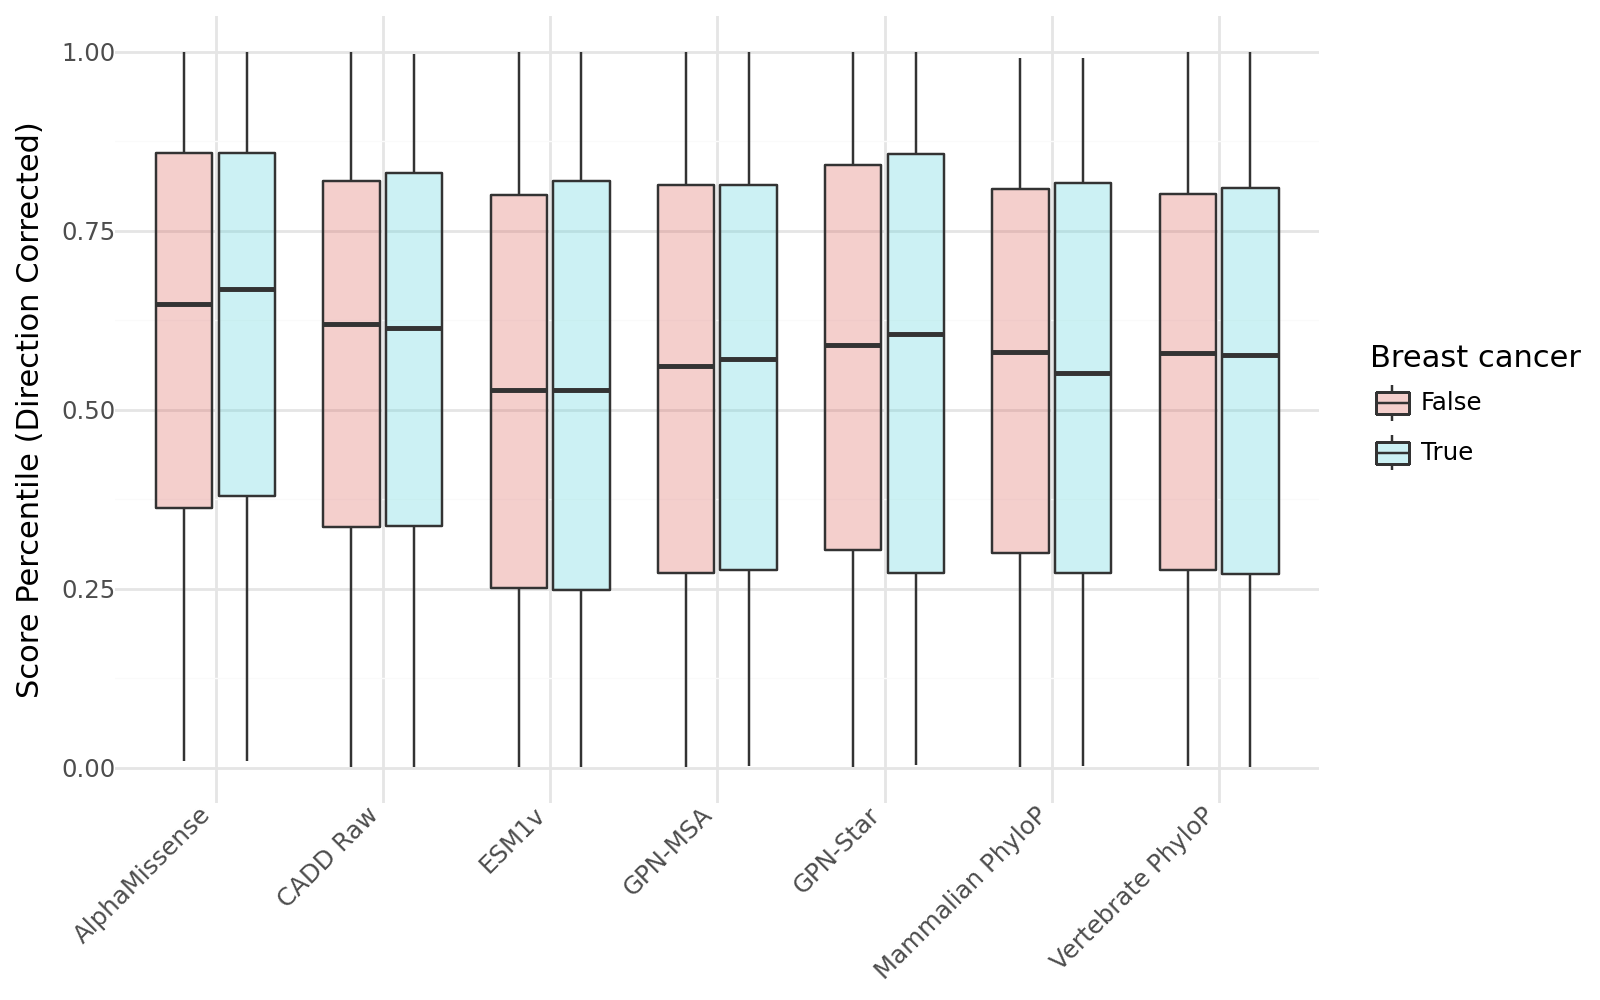

In [21]:
# annos2plot = ['am_pathogenicity', 'cadd_raw', 'gpn_score', 'SGE_HAP1', 'SGE_EScell', 'zooverphylop', 'verphylop']
# pheno_gis_dircorr.filter(pl.col('annotation').is_in(annos2plot))
plot_df = pheno_gis_dircorr.with_columns(
    pheno_bool = pl.col('pheno_value') > 0
)

(
    ggplot(plot_df, aes(x='label', y='score_ptile_dircorr', fill='pheno_bool')) +
    geom_boxplot(alpha=0.3) +
    theme_minimal() +
    labs(
        x='',
        y='Score Percentile (Direction Corrected)',
        fill='Breast cancer'
    ) +
    theme(
        figure_size=(8, 5),
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

### AUC

In [22]:
def compute_auc(pheno_value, anno_score) -> float:
    try:
        return roc_auc_score(pheno_value, anno_score)
    except ValueError:  # e.g., only one class present
        return np.nan
    
auc_df = (
    pheno_gis_dircorr.lazy()
    .group_by(['annotation', 'label', 'phenotype', 'region'])
    .map_groups(lambda df: pl.DataFrame({
        "annotation": [df["annotation"][0]],
        "label": [df["label"][0]],
        "phenotype": [df["phenotype"][0]],
        "region": [df["region"][0]],
        "auc": [compute_auc(df['pheno_value'], df['score_dircorr'])],
        "n_variants": [df['id'].n_unique()]
        }),
        schema={"auc": pl.Float64, "n_variants": pl.Int64}
    )
    .drop_nulls(subset=['auc'])
    .sort('auc', descending=True)
).collect(engine='streaming')

auc_df

annotation,label,phenotype,region,auc,n_variants
str,str,str,str,f64,i64
"""gpn_star_llr_calibrated_mean""","""GPN-Star""","""jurgens_breast_cancer""","""ENSG00000139618""",0.505114,1112
"""am_pathogenicity""","""AlphaMissense""","""jurgens_breast_cancer""","""ENSG00000139618""",0.503982,1112
"""gpn_score""","""GPN-MSA""","""jurgens_breast_cancer""","""ENSG00000139618""",0.503673,1112
"""cadd_raw""","""CADD Raw""","""jurgens_breast_cancer""","""ENSG00000139618""",0.502824,1112
"""verphylop""","""Vertebrate PhyloP""","""jurgens_breast_cancer""","""ENSG00000139618""",0.498481,1112
"""mamphylop""","""Mammalian PhyloP""","""jurgens_breast_cancer""","""ENSG00000139618""",0.4973,1112
"""esmscoremissense""","""ESM1v""","""jurgens_breast_cancer""","""ENSG00000139618""",0.492225,1112


In [23]:

from sklearn.metrics import roc_auc_score

def compute_auc(pheno_value: pl.Series, anno_score: pl.Series) -> float:
    try:
        if pheno_value.n_unique() < 2:
            return np.nan
        return roc_auc_score(pheno_value, anno_score)
    except ValueError:
        return np.nan

def compute_bootstrapped_auc_ci(
    df_group: pl.DataFrame, n_bootstraps: int = 1000, alpha: float = 0.05
) -> pl.DataFrame:
    """
    Performs bootstrapping on a dataframe group to calculate the mean AUC and confidence intervals.
    """
    bootstrapped_aucs = []
    for _ in range(n_bootstraps):
        # Create a bootstrap sample by sampling with replacement
        df_sample = df_group.sample(fraction=1.0, with_replacement=True)
        
        # Compute AUC for the current bootstrap sample
        auc = compute_auc(df_sample['pheno_value'], df_sample['score_dircorr'])
        
        if not np.isnan(auc):
            bootstrapped_aucs.append(auc)

    # If all bootstrap attempts failed, return NaNs
    if not bootstrapped_aucs:
        return pl.DataFrame({
            "auc_mean": [np.nan], "auc_ci_lower": [np.nan], "auc_ci_upper": [np.nan]
        })

    # Calculate mean and percentile-based confidence intervals
    # For a 95% CI (alpha=0.05), we use the 2.5th and 97.5th percentiles
    lower_p = (alpha / 2.0) * 100
    upper_p = (1.0 - alpha / 2.0) * 100
    
    auc_mean = np.mean(bootstrapped_aucs)
    auc_ci_lower = np.percentile(bootstrapped_aucs, lower_p)
    auc_ci_upper = np.percentile(bootstrapped_aucs, upper_p)
    
    # Return results as a Polars DataFrame
    return pl.DataFrame({
        "auc_mean": [auc_mean],
        "auc_ci_lower": [auc_ci_lower],
        "auc_ci_upper": [auc_ci_upper],
    })

N_BOOTSTRAPS = 1000  # Set the number of bootstrap iterations

auc_bootstrap_df = (
    pheno_gis_dircorr.lazy()
    .group_by(['annotation', 'label', 'phenotype', 'region'])
    .map_groups(
        lambda df: (
            # Run the bootstrapping function on the entire group
            compute_bootstrapped_auc_ci(df, n_bootstraps=N_BOOTSTRAPS)
            # Add back the identifier columns and variant count
            .with_columns(
                annotation=pl.lit(df["annotation"][0]),
                label=pl.lit(df["label"][0]),
                phenotype=pl.lit(df["phenotype"][0]),
                region=pl.lit(df["region"][0]),
                n_variants=pl.lit(df['id'].n_unique())
            )
        ),
        # Define the new schema for the output
        schema={
            "auc_mean": pl.Float64,
            "auc_ci_lower": pl.Float64,
            "auc_ci_upper": pl.Float64,
            "annotation": pl.String,
            "label": pl.String,
            "phenotype": pl.String,
            "region": pl.String,
            "n_variants": pl.Int64
        }
    )
    .drop_nulls(subset=['auc_mean'])
    .sort('auc_mean', descending=True)
).collect(engine='streaming')

auc_bootstrap_df = auc_df.join(auc_bootstrap_df, on=['annotation', 'label', 'phenotype', 'region', 'n_variants'])
auc_bootstrap_df

annotation,label,phenotype,region,auc,n_variants,auc_mean,auc_ci_lower,auc_ci_upper
str,str,str,str,f64,i64,f64,f64,f64
"""gpn_star_llr_calibrated_mean""","""GPN-Star""","""jurgens_breast_cancer""","""ENSG00000139618""",0.505114,1112,0.505004,0.482825,0.527365
"""am_pathogenicity""","""AlphaMissense""","""jurgens_breast_cancer""","""ENSG00000139618""",0.503982,1112,0.50377,0.481604,0.525276
"""gpn_score""","""GPN-MSA""","""jurgens_breast_cancer""","""ENSG00000139618""",0.503673,1112,0.503591,0.47938,0.525157
"""cadd_raw""","""CADD Raw""","""jurgens_breast_cancer""","""ENSG00000139618""",0.502824,1112,0.502697,0.479524,0.525364
"""verphylop""","""Vertebrate PhyloP""","""jurgens_breast_cancer""","""ENSG00000139618""",0.498481,1112,0.49721,0.477733,0.517671
"""mamphylop""","""Mammalian PhyloP""","""jurgens_breast_cancer""","""ENSG00000139618""",0.4973,1112,0.496496,0.473888,0.51687
"""esmscoremissense""","""ESM1v""","""jurgens_breast_cancer""","""ENSG00000139618""",0.492225,1112,0.492566,0.469591,0.515992


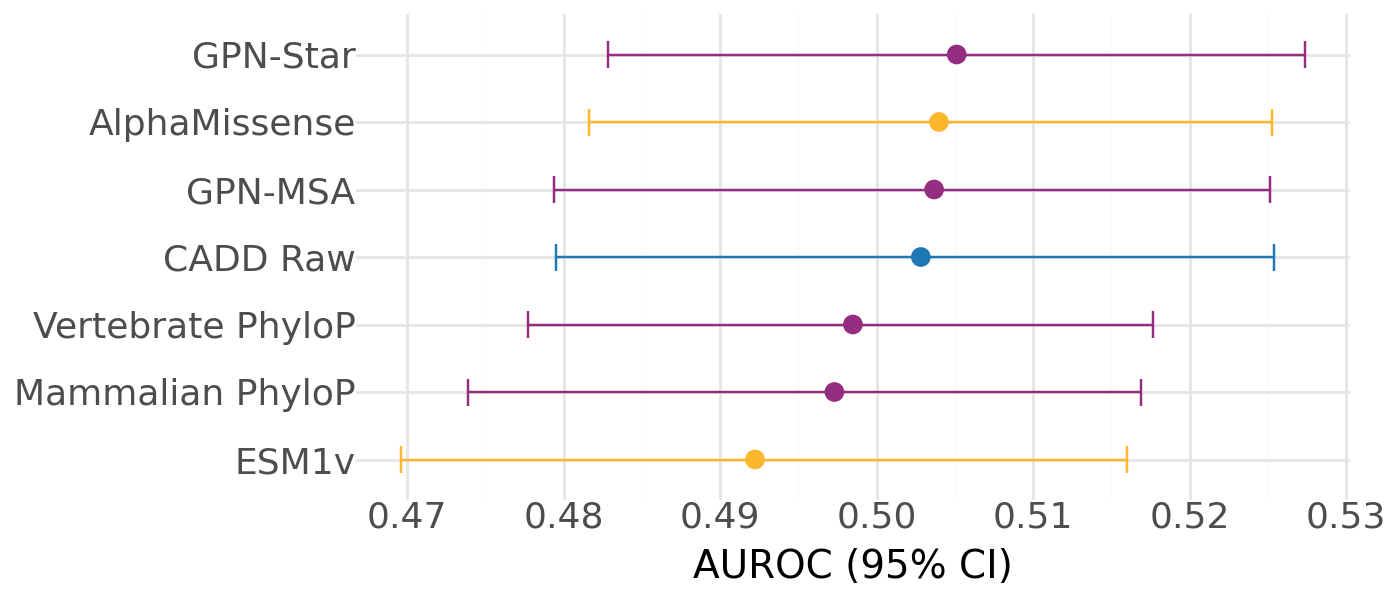

In [24]:
auc_plot_df = auc_bootstrap_df.to_pandas()

# Ordering by mean correlation
auc_plot_df['label'] = pd.Categorical(
    auc_plot_df['label'],
    categories=auc_plot_df.sort_values('auc', ascending=True)['label'],
    ordered=True
)

color_dict = dict(zip(anno_config_df['label'], anno_config_df['color']))

(
    ggplot(auc_plot_df, aes(x='label', y='auc', color='label')) +
    geom_point(size=3) +
    geom_errorbar(aes(ymin='auc_ci_lower', ymax='auc_ci_upper'), width=0.4) +
    coord_flip() +
    theme_minimal() +
    scale_color_manual(values=color_dict) +
    labs(
        x='',
        y='AUROC (95% CI)'
    ) +
    theme(
        figure_size=(7, 3),
        legend_position='none',
        axis_text=element_text(size=13),
        axis_title=element_text(size=14),
        legend_text=element_text(size=13),
        legend_title=element_text(size=14),
    )
)

### Odds ratio

$$
\mathrm{OR} \;=\; \frac{\dfrac{N(\text{disease}>\text{GIS}) + 1}{N(\text{not disease}>\text{GIS}) + 1}}{\dfrac{N(\text{disease}<\text{GIS}) + 1}{N(\text{not disease}<\text{GIS}) + 1}}
$$

$$
\mathrm{Enrichment} \;=\; \frac{\dfrac{N(\text{disease}>\text{GIS}) + 1}{N(\text{not disease}>\text{GIS}) + 1}}{\dfrac{N(\text{disease})}{N(\text{not disease})}}
$$

In [25]:
or_df_list = []
for p_itr in tqdm(range(pheno_gis_dircorr['n_variants'][0])):
    ptile_cutoff = p_itr/pheno_gis_dircorr['n_variants'][0]

    or_temp = (
        pheno_gis_dircorr.group_by(
            ["annotation", "label", "region", "phenotype"]
        )
        .agg(
            n_dis_above_cutoff = ((pl.col("pheno_value")==1) & (pl.col("score_ptile_dircorr")>=ptile_cutoff)).sum(),
            n_not_dis_above_cutoff = ((pl.col("pheno_value")==0) & (pl.col("score_ptile_dircorr")>=ptile_cutoff)).sum(),
            n_dis_below_cutoff = ((pl.col("pheno_value")==1) & (pl.col("score_ptile_dircorr")<ptile_cutoff)).sum(),
            n_not_dis_below_cutoff = ((pl.col("pheno_value")==0) & (pl.col("score_ptile_dircorr")<ptile_cutoff)).sum(),
            total_dis = (pl.col("pheno_value")==1).sum(),
            total_not_dis = (pl.col("pheno_value")==0).sum()
        )
        .with_columns(
            ptile_cutoff = pl.lit(ptile_cutoff),
            enrichment = ((pl.col("n_dis_above_cutoff")+1) / (pl.col("n_not_dis_above_cutoff")+1))/(pl.col("total_dis")/pl.col("total_not_dis")),
            odds_ratio = ((pl.col("n_dis_above_cutoff")+1) / (pl.col("n_dis_below_cutoff")+1)) / ((pl.col("n_not_dis_above_cutoff")+1) / (pl.col("n_not_dis_below_cutoff")+1))
        )
    )

    or_df_list.append(or_temp)

or_df = pl.concat(or_df_list)
or_df

100%|██████████| 1112/1112 [00:02<00:00, 383.59it/s]


annotation,label,region,phenotype,n_dis_above_cutoff,n_not_dis_above_cutoff,n_dis_below_cutoff,n_not_dis_below_cutoff,total_dis,total_not_dis,ptile_cutoff,enrichment,odds_ratio
str,str,str,str,u64,u64,u64,u64,u64,u64,f64,f64,f64
"""esmscoremissense""","""ESM1v""","""ENSG00000139618""","""jurgens_breast_cancer""",754,7903,0,0,754,7903,0.0,1.0012,0.095521
"""am_pathogenicity""","""AlphaMissense""","""ENSG00000139618""","""jurgens_breast_cancer""",754,7903,0,0,754,7903,0.0,1.0012,0.095521
"""verphylop""","""Vertebrate PhyloP""","""ENSG00000139618""","""jurgens_breast_cancer""",754,7903,0,0,754,7903,0.0,1.0012,0.095521
"""gpn_score""","""GPN-MSA""","""ENSG00000139618""","""jurgens_breast_cancer""",754,7903,0,0,754,7903,0.0,1.0012,0.095521
"""cadd_raw""","""CADD Raw""","""ENSG00000139618""","""jurgens_breast_cancer""",754,7903,0,0,754,7903,0.0,1.0012,0.095521
…,…,…,…,…,…,…,…,…,…,…,…,…
"""verphylop""","""Vertebrate PhyloP""","""ENSG00000139618""","""jurgens_breast_cancer""",1,8,753,7895,754,7903,0.999101,2.329207,2.327144
"""mamphylop""","""Mammalian PhyloP""","""ENSG00000139618""","""jurgens_breast_cancer""",0,0,754,7903,754,7903,0.999101,10.481432,10.468874
"""esmscoremissense""","""ESM1v""","""ENSG00000139618""","""jurgens_breast_cancer""",1,10,753,7893,754,7903,0.999101,1.905715,1.903545


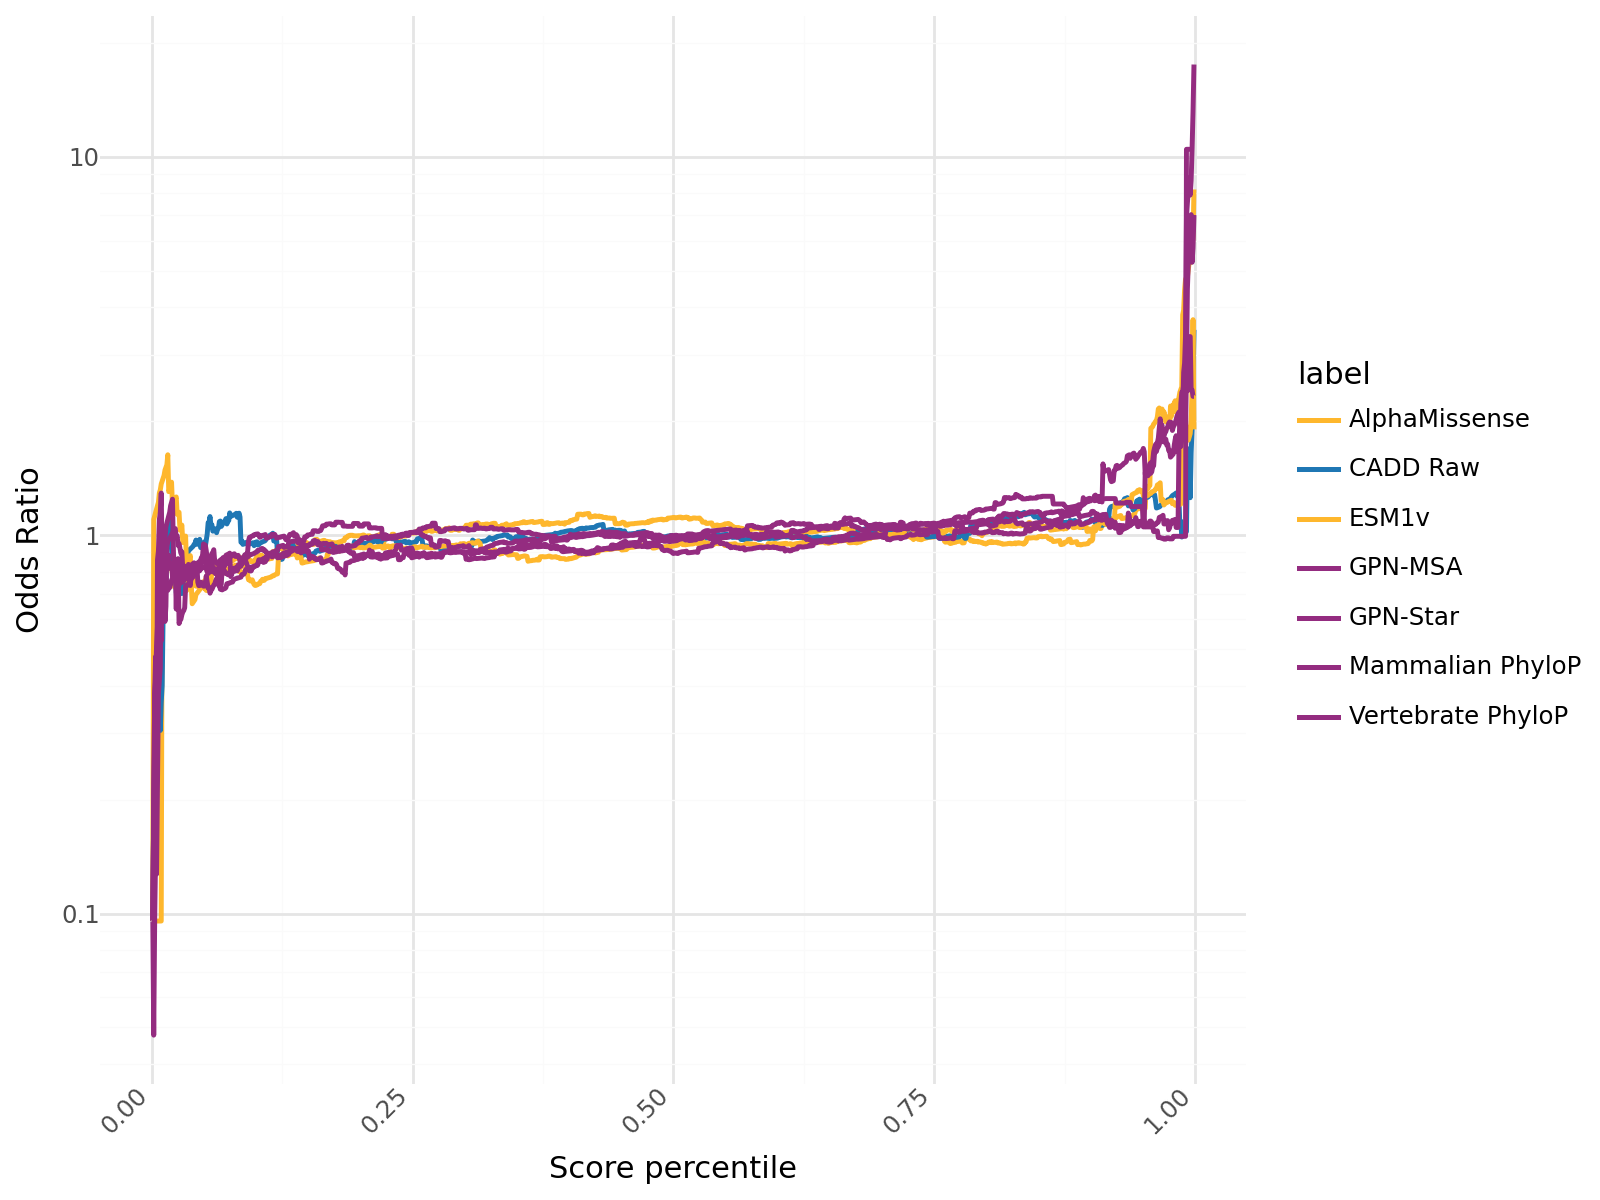

In [26]:
color_dict = dict(zip(anno_config_df['label'], anno_config_df['color']))

(
    ggplot(or_df, aes(x='ptile_cutoff', y='odds_ratio', color='label')) +
    geom_line(size=1) +
    theme_minimal() +
    scale_y_log10() +
    scale_color_manual(values=color_dict) +
    labs(
        x='Score percentile',
        y='Odds Ratio'
    ) +
    theme(
        figure_size=(8, 6),
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

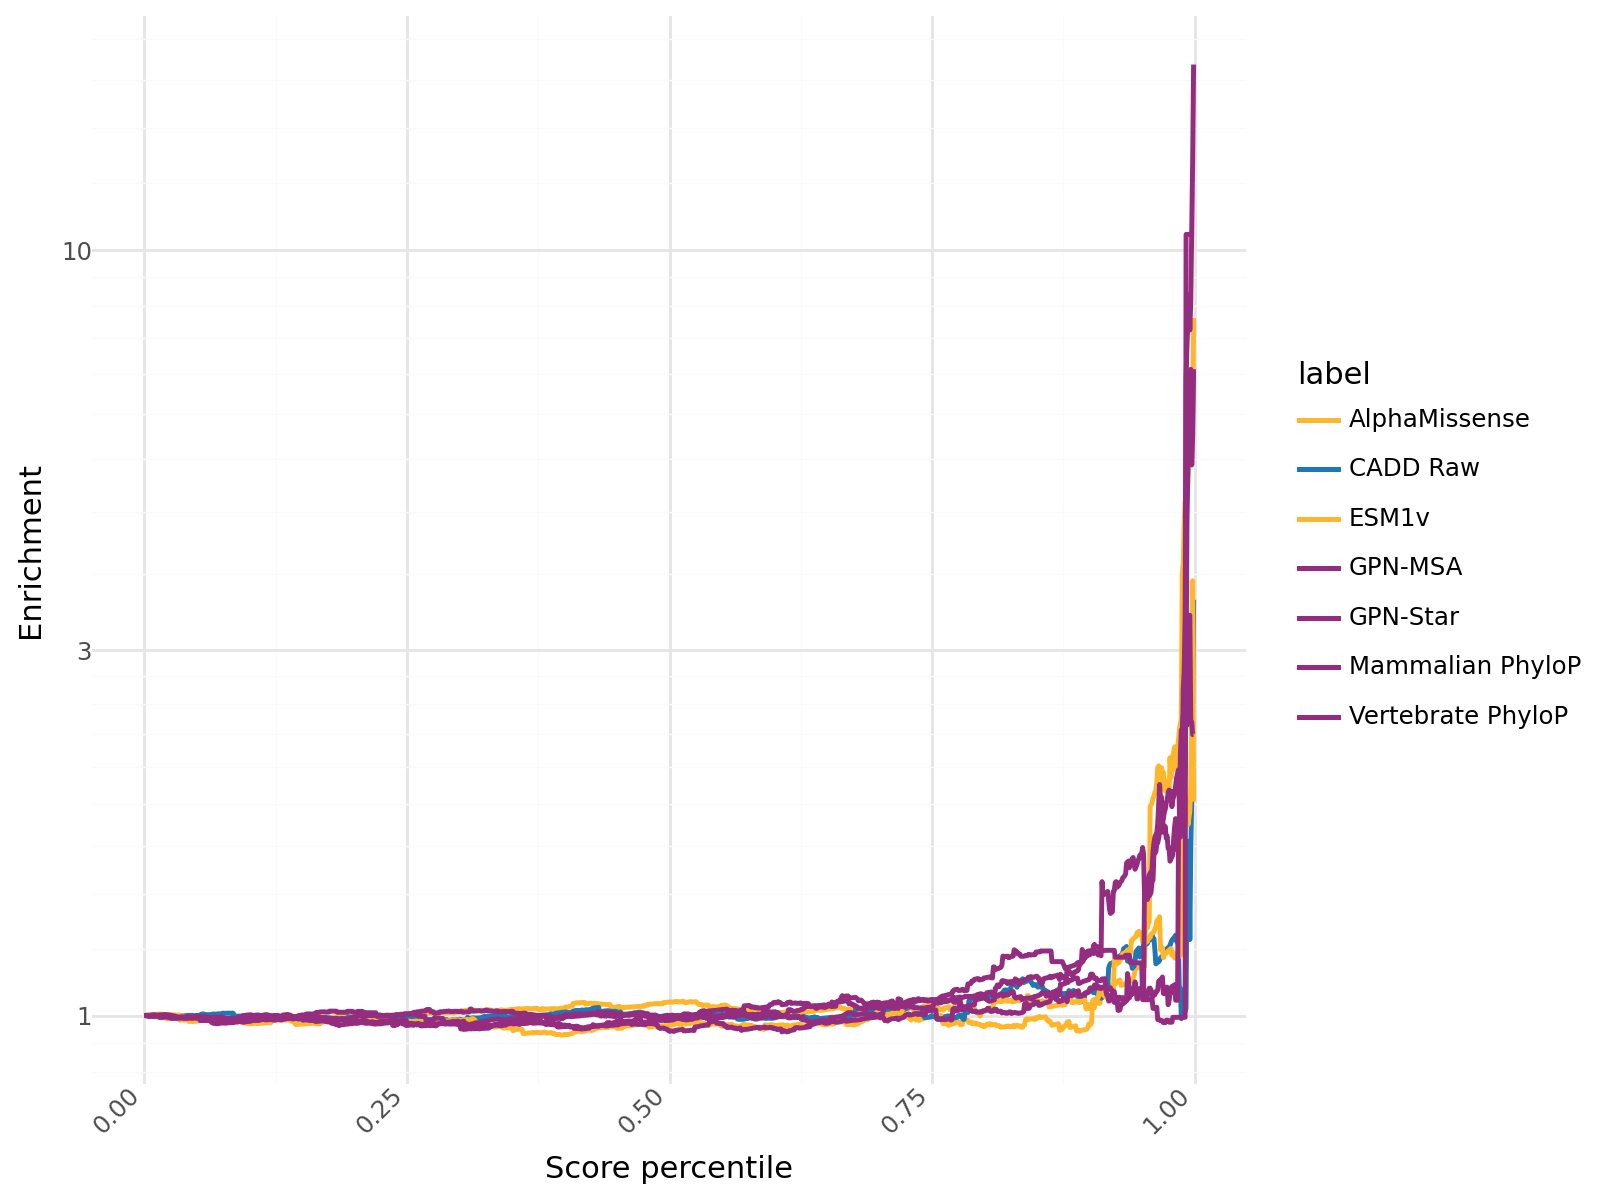

In [27]:
color_dict = dict(zip(anno_config_df['label'], anno_config_df['color']))

(
    ggplot(or_df, aes(x='ptile_cutoff', y='enrichment', color='label')) +
    geom_line(size=1) +
    theme_minimal() +
    scale_y_log10() +
    scale_color_manual(values=color_dict) +
    labs(
        x='Score percentile',
        y='Enrichment'
    ) +
    theme(
        figure_size=(8, 6),
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)